# NOTEBOOK 11b_RANDOM — SESSIONISATION + LEARNING TO RANK
## Version split aléatoire per-user (problématique SPARSITÉ pure)

**Différence avec NB11b original** :
- ✅ **Mêmes features** (66 features Config D)
- ✅ **Mêmes 4 configurations** (A, B, C, D)
- ✅ **Mêmes paramètres GB** + 5-fold CV

**Pourquoi ce changement ?**
Le split par présentation de NB11b original génère 92.7% de cold-start dans le test set,
ce qui mélange artificiellement les problématiques *sparsité* et *cold-start user*.

Avec un split per-user chronologique :
- Chaque étudiant a ses 80% premières interactions (chronologiques) en TRAIN
- Et ses 20% dernières interactions en TEST
- → Tous les étudiants sont WARM dans les deux splits
- → On évalue uniquement la capacité du modèle à prédire les interactions futures
  d'étudiants déjà vus (= problématique sparsité pure)
- → Anti-leakage temporel garanti (pas de futur dans le train)

**Objectif** : obtenir une **vraie mesure** de la performance sur la problématique sparsité,
sans contamination par le cold-start user (qui sera traité dans NB14 dédié).

**Rappel** : les features `*_hist` (avg_score_hist, etc.) restent calculées via window function
chronologique, donc l'anti-leakage intra-étudiant est préservé par construction.

In [2]:
import os, subprocess, sys

# Utiliser Java 17 (OpenJDK 11 n'est plus dispo sur Ubuntu 22.04 via apt)
result = subprocess.run(
    ["apt-get", "install", "-y", "openjdk-17-jdk-headless", "-qq"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if result.stdout else "")
print(result.stderr[-500:] if result.stderr else "")

# Pointer JAVA_HOME vers Java 17
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# Vérifier que java est bien trouvé
!java -version

# Installer PySpark compatible
!pip install pyspark==3.5.3 -q

print("✅ Java + Spark installés")


E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/universe/o/openjdk-17/openjdk-17-jdk-headless_17.0.18%2b8-1%7e22.04.1_amd64.deb  404  Not Found [IP: 172.66.152.176 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/universe/o/openjdk-17/openjdk-17-jre-headless_17.0.18%2b8-1%7e22.04.1_amd64.deb  404  Not Found [IP: 172.66.152.176 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?

openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 5.3 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 11.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency co

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.sql.types import FloatType, IntegerType
import numpy as np
import pandas as pd
import builtins
import json, os
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName("NB11b_RANDOM_Sessionisation") \
    .master("local[*]") \
    .config("spark.driver.memory", "6g") \
    .config("spark.sql.shuffle.partitions", "20") \
    .getOrCreate()

print(f"✅ Spark {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/19 00:14:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark 3.5.3


In [4]:
print("="*70)
print("📂 CELLULE 2 — CHARGEMENT DES DONNÉES")
print("="*70)

OULAD    = "/kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/"
FUSED    = "/kaggle/input/datasets/mohamedlkhalidi/oulad-scores-fused/oulad_scores_fused.csv"
STUDENTS = "/kaggle/input/datasets/mohamedlkhalidi/oulad-students-silver/oulad_students_silver.csv"

df_scores        = spark.read.csv(FUSED,                        header=True, inferSchema=True)
df_assessments   = spark.read.csv(OULAD + "assessments.csv",    header=True, inferSchema=True)
df_vle_clicks    = spark.read.csv(OULAD + "studentVle.csv",     header=True, inferSchema=True)
df_vle_resources = spark.read.csv(OULAD + "vle.csv",            header=True, inferSchema=True)
df_students      = spark.read.csv(STUDENTS,                     header=True, inferSchema=True)
df_courses       = spark.read.csv(OULAD + "courses.csv",        header=True, inferSchema=True)

print(f"   Scores+Sentiment  : {df_scores.count():,}")
print(f"   Assessments       : {df_assessments.count():,}")
print(f"   Clics VLE         : {df_vle_clicks.count():,}")
print(f"   Courses           : {df_courses.count():,}")

📂 CELLULE 2 — CHARGEMENT DES DONNÉES


   Scores+Sentiment  : 179,263
   Assessments       : 206


   Clics VLE         : 10,655,280
   Courses           : 22


In [5]:
print("="*70)
print("📂 CELLULE 3 — TIMELINE DES ASSESSMENTS PAR MODULE (avec Exams)")
print("="*70)
print("""
   Inclut les Exams. Les Exams n'ont pas de date dans OULAD →
   on leur assigne la date de fin du module (module_presentation_length).
""")

df_assess_with_length = df_assessments \
    .join(df_courses.select("code_module", "code_presentation", "module_presentation_length"),
          on=["code_module", "code_presentation"], how="left")

df_assess_dates = df_assess_with_length \
    .withColumn("date_safe", expr("TRY_CAST(date AS INT)")) \
    .withColumn("assess_date",
        when(col("date_safe").isNull(), col("module_presentation_length").cast("int"))
        .otherwise(col("date_safe"))
    ) \
    .filter(col("assess_date").isNotNull()) \
    .select("id_assessment", "code_module", "code_presentation",
            "assess_date", "assessment_type", "weight")

n_with_date = df_assess_dates.filter(col("assessment_type") != "Exam").count()
n_exams = df_assess_dates.filter(col("assessment_type") == "Exam").count()
print(f"   Assessments avec date originale: {n_with_date}")
print(f"   Exams (date = fin module):       {n_exams}")
print(f"   Total:                           {df_assess_dates.count()}")

# Périodes inter-assessment
w_assess = Window.partitionBy("code_module", "code_presentation") \
    .orderBy("assess_date")

df_assess_periods = df_assess_dates \
    .withColumn("prev_assess_date", lag("assess_date").over(w_assess)) \
    .withColumn("period_start",
        when(col("prev_assess_date").isNull(), lit(-30))
        .otherwise(col("prev_assess_date") + 1)) \
    .withColumn("period_end", col("assess_date"))

📂 CELLULE 3 — TIMELINE DES ASSESSMENTS PAR MODULE (avec Exams)

   Inclut les Exams. Les Exams n'ont pas de date dans OULAD →
   on leur assigne la date de fin du module (module_presentation_length).

   Assessments avec date originale: 182
   Exams (date = fin module):       24
   Total:                           206


In [6]:
print("="*70)
print("📂 CELLULE 4 — FEATURES DE SESSION PAR PÉRIODE")
print("="*70)

# Joindre clics VLE avec le type de ressource
df_vle_typed = df_vle_clicks \
    .join(df_vle_resources.select("id_site", "activity_type"),
          on="id_site", how="inner")

# 1 session = 1 jour actif
df_daily_sessions = df_vle_typed \
    .groupBy("id_student", "code_module", "code_presentation", "date") \
    .agg(
        sum("sum_click").alias("day_clicks"),
        count_distinct("id_site").alias("day_resources"),
        count_distinct("activity_type").alias("day_activity_types")
    )

print(f"   Sessions (jours) totales: {df_daily_sessions.count():,}")

# Joindre scores + périodes assessment
df_student_assess = df_scores \
    .join(df_assess_periods.select("id_assessment", "code_module", "code_presentation",
                                    "period_start", "period_end"),
          on="id_assessment", how="inner")

# Sessions dans la période
df_sessions_per_assess = df_student_assess \
    .join(
        df_daily_sessions,
        on=["id_student", "code_module", "code_presentation"],
        how="inner"
    ) \
    .filter(
        (col("date") >= col("period_start")) &
        (col("date") <= col("period_end"))
    )

# Agrégation features de session par (étudiant, assessment)
df_session_features = df_sessions_per_assess \
    .groupBy("id_student", "id_assessment", "code_module", "code_presentation") \
    .agg(
        count("*").alias("n_sessions"),
        avg("day_clicks").alias("avg_clicks_per_session"),
        stddev("day_clicks").alias("std_clicks_per_session"),
        max("day_clicks").alias("max_session_clicks"),
        min("day_clicks").alias("min_session_clicks"),
        sum("day_clicks").alias("total_period_clicks"),
        avg("day_resources").alias("avg_resources_per_session"),
        avg("day_activity_types").alias("avg_types_per_session")
    ) \
    .fillna(0)

session_cols = ['n_sessions', 'avg_clicks_per_session', 'std_clicks_per_session',
                'max_session_clicks', 'min_session_clicks', 'total_period_clicks',
                'avg_resources_per_session', 'avg_types_per_session']

print(f"   Features de session calculées: {len(session_cols)}")
print(f"   Paires (étudiant, assessment) avec sessions: {df_session_features.count():,}")

📂 CELLULE 4 — FEATURES DE SESSION PAR PÉRIODE


   Sessions (jours) totales: 1,808,119
   Features de session calculées: 8


   Paires (étudiant, assessment) avec sessions: 126,098


In [7]:
print("="*70)
print("📂 CELLULE 4b — FEATURES VLE GLOBALES + TEMPORELLES (par module)")
print("="*70)

# VLE globales par type
df_vle_global_by_type = df_vle_typed \
    .groupBy("id_student", "code_module", "code_presentation") \
    .pivot("activity_type") \
    .agg(sum("sum_click")) \
    .fillna(0)

global_activity_types = [c for c in df_vle_global_by_type.columns
                         if c not in ['id_student', 'code_module', 'code_presentation']]

for t in global_activity_types:
    df_vle_global_by_type = df_vle_global_by_type.withColumnRenamed(t, f"clicks_{t}")

global_vle_cols = [f"clicks_{t}" for t in global_activity_types]
print(f"   Features VLE globales (par module): {len(global_vle_cols)}")

# Temporelles globales
df_temporal = df_vle_clicks \
    .groupBy("id_student", "code_module", "code_presentation") \
    .agg(
        count_distinct("date").alias("n_active_days"),
        stddev("date").alias("std_days_activity"),
        min("date").alias("first_activity_day"),
        max("date").alias("last_activity_day")
    ) \
    .fillna(0)

df_temporal = df_temporal \
    .withColumn("engagement_span",
        (col("last_activity_day") - col("first_activity_day")).cast("float")) \
    .drop("last_activity_day")

temporal_cols = ['n_active_days', 'std_days_activity', 'first_activity_day', 'engagement_span']
print(f"   Features temporelles (par module): {temporal_cols}")

📂 CELLULE 4b — FEATURES VLE GLOBALES + TEMPORELLES (par module)


   Features VLE globales (par module): 20
   Features temporelles (par module): ['n_active_days', 'std_days_activity', 'first_activity_day', 'engagement_span']


In [8]:
print("="*70)
print("📂 CELLULE 5 — CLICS VLE PAR TYPE ET PAR PÉRIODE")
print("="*70)

df_vle_in_period = df_vle_typed \
    .join(
        df_student_assess.select("id_student", "id_assessment",
                                  "code_module", "code_presentation",
                                  "period_start", "period_end"),
        on=["id_student", "code_module", "code_presentation"],
        how="inner"
    ) \
    .filter(
        (col("date") >= col("period_start")) &
        (col("date") <= col("period_end"))
    )

df_vle_period_by_type = df_vle_in_period \
    .groupBy("id_student", "id_assessment") \
    .pivot("activity_type") \
    .agg(sum("sum_click")) \
    .fillna(0)

activity_types = [c for c in df_vle_period_by_type.columns
                  if c not in ['id_student', 'id_assessment']]
for t in activity_types:
    df_vle_period_by_type = df_vle_period_by_type.withColumnRenamed(t, f"period_clicks_{t}")

period_vle_cols = [f"period_clicks_{t}" for t in activity_types]
print(f"   Types d'activité: {len(activity_types)}")
print(f"   Paires avec clics par type: {df_vle_period_by_type.count():,}")

📂 CELLULE 5 — CLICS VLE PAR TYPE ET PAR PÉRIODE


   Types d'activité: 20


   Paires avec clics par type: 126,098


In [9]:
print("="*70)
print("📂 CELLULE 6 — FEATURES DÉMOGRAPHIQUES")
print("="*70)

df_demo = df_students \
    .select("id_student", "code_module", "code_presentation",
            "gender", "age_band_num", "education_level",
            "imd_band", "num_of_prev_attempts") \
    .dropDuplicates(["id_student", "code_module", "code_presentation"]) \
    .withColumn("gender_num", when(col("gender") == "M", 1).otherwise(0)) \
    .withColumn("imd_band_num",
        when(col("imd_band") == "0-10%", 1)
        .when(col("imd_band") == "10-20", 2)
        .when(col("imd_band") == "20-30%", 3)
        .when(col("imd_band") == "30-40%", 4)
        .when(col("imd_band") == "40-50%", 5)
        .when(col("imd_band") == "50-60%", 6)
        .when(col("imd_band") == "60-70%", 7)
        .when(col("imd_band") == "70-80%", 8)
        .when(col("imd_band") == "80-90%", 9)
        .when(col("imd_band") == "90-100%", 10)
        .otherwise(5)) \
    .drop("gender", "imd_band") \
    .fillna(0)

demo_cols = ['gender_num', 'age_band_num', 'education_level',
             'imd_band_num', 'num_of_prev_attempts']
print(f"   Features: {demo_cols}")
print(f"   Lignes: {df_demo.count():,}")

📂 CELLULE 6 — FEATURES DÉMOGRAPHIQUES
   Features: ['gender_num', 'age_band_num', 'education_level', 'imd_band_num', 'num_of_prev_attempts']
   Lignes: 32,593


In [10]:
print("="*70)
print("📂 CELLULE 7 — FEATURES HISTORIQUES ANTI-LEAKAGE (par étudiant chronologique)")
print("="*70)
print("""
   ⚠ IMPORTANT: les features `*_hist` sont calculées via window function
   chronologique PAR ÉTUDIANT. Donc l'anti-leakage temporel intra-étudiant
   est préservé QUEL QUE SOIT le split.
""")

df_base = df_scores \
    .join(df_assess_dates.select("id_assessment", "code_module", "code_presentation", "assess_date"),
          on="id_assessment", how="inner")

print(f"   Interactions totales: {df_base.count():,}")

w_hist = Window.partitionBy("id_student", "code_module", "code_presentation") \
    .orderBy("assess_date") \
    .rowsBetween(Window.unboundedPreceding, -1)

df_with_hist = df_base \
    .withColumn("avg_score_hist", avg("score").over(w_hist)) \
    .withColumn("std_score_hist", stddev("score").over(w_hist)) \
    .withColumn("min_score_hist", min("score").over(w_hist)) \
    .withColumn("max_score_hist", max("score").over(w_hist)) \
    .withColumn("avg_sent_hist", avg("sentiment_score").over(w_hist)) \
    .withColumn("std_sent_hist", stddev("sentiment_score").over(w_hist)) \
    .withColumn("min_sent_hist", min("sentiment_score").over(w_hist)) \
    .withColumn("max_sent_hist", max("sentiment_score").over(w_hist)) \
    .withColumn("n_completed_hist", count("score").over(w_hist))

df_with_hist = df_with_hist.filter(col("n_completed_hist") > 0)

df_with_hist = df_with_hist \
    .withColumn("label", when(col("score") > 50, 1).otherwise(0)) \
    .fillna(0)

hist_score_cols = ['avg_score_hist', 'std_score_hist', 'min_score_hist',
                   'max_score_hist', 'n_completed_hist']
hist_sent_cols = ['avg_sent_hist', 'std_sent_hist', 'min_sent_hist', 'max_sent_hist']

n_total = df_with_hist.count()
n_pos = df_with_hist.filter(col("label") == 1).count()
print(f"   Paires avec historique: {n_total:,}")
print(f"   Label=1: {n_pos:,} ({n_pos/n_total*100:.1f}%)")
print(f"   Label=0: {n_total-n_pos:,} ({(n_total-n_pos)/n_total*100:.1f}%)")

📂 CELLULE 7 — FEATURES HISTORIQUES ANTI-LEAKAGE (par étudiant chronologique)

   ⚠ IMPORTANT: les features `*_hist` sont calculées via window function
   chronologique PAR ÉTUDIANT. Donc l'anti-leakage temporel intra-étudiant
   est préservé QUEL QUE SOIT le split.

   Interactions totales: 173,739


   Paires avec historique: 147,919
   Label=1: 134,144 (90.7%)
   Label=0: 13,775 (9.3%)


In [11]:
print("="*70)
print("📂 CELLULE 8 — ASSEMBLAGE DU VECTEUR COMPLET")
print("="*70)

df_full = df_with_hist \
    .join(df_vle_global_by_type,
          on=["id_student", "code_module", "code_presentation"], how="left") \
    .join(df_temporal,
          on=["id_student", "code_module", "code_presentation"], how="left") \
    .join(df_session_features,
          on=["id_student", "id_assessment", "code_module", "code_presentation"], how="left") \
    .join(df_vle_period_by_type,
          on=["id_student", "id_assessment"], how="left") \
    .join(df_demo,
          on=["id_student", "code_module", "code_presentation"], how="left") \
    .fillna(0)

# Groupes de features
features_vle_global = global_vle_cols
features_temporal = temporal_cols
features_demo = demo_cols
features_score_hist = hist_score_cols
features_sent_hist = hist_sent_cols
features_session = session_cols
features_vle_period = period_vle_cols

# 4 configurations
features_nb11_base = features_vle_global + features_temporal + features_demo + features_score_hist
features_nb11_sent = features_nb11_base + features_sent_hist
features_nb11b_base = features_nb11_base + features_session + features_vle_period
features_nb11b_all = features_nb11b_base + features_sent_hist

print(f"   CONFIG A (NB11 base):              {len(features_nb11_base)} features")
print(f"   CONFIG B (NB11 + sentiment):       {len(features_nb11_sent)} features")
print(f"   CONFIG C (NB11 + session):         {len(features_nb11b_base)} features")
print(f"   CONFIG D (NB11 + session + sent):  {len(features_nb11b_all)} features")
print(f"\n   Lignes: {df_full.count():,}")

# Vérif anti-leakage
assert "score" not in features_nb11b_all
assert "sentiment_score" not in features_nb11b_all
print(f"   ✅ Aucun leakage de features cibles")

📂 CELLULE 8 — ASSEMBLAGE DU VECTEUR COMPLET
   CONFIG A (NB11 base):              34 features
   CONFIG B (NB11 + sentiment):       38 features
   CONFIG C (NB11 + session):         62 features
   CONFIG D (NB11 + session + sent):  66 features



   Lignes: 147,919
   ✅ Aucun leakage de features cibles


In [12]:
print("="*70)
print("📂 CELLULE 9 — SPLIT PER-USER 80/20 CHRONOLOGIQUE")
print("="*70)
print("""
   ⚠ NOUVEAU PROTOCOLE — différent de NB11b original
   
   Pour CHAQUE étudiant ayant ≥ 2 interactions :
   - Trier ses interactions par assess_date (ordre chronologique)
   - 80% premières (en temps) → TRAIN
   - 20% dernières (en temps) → TEST
   
   Avantages :
   ✅ Tous les étudiants présents en train ET en test → tous WARM
   ✅ Pas de fuite temporelle intra-étudiant (le futur reste dans le test)
   ✅ Évalue purement la SPARSITÉ (capacité à compléter des interactions manquantes)
   ✅ Comparable aux protocoles standards de RecSys (per-user temporal split)
""")

all_feature_cols = list(set(features_nb11b_all))

# Conversion vers Pandas
pdf = df_full.select(
    all_feature_cols + ["label", "id_student", "code_module", "code_presentation",
                         "id_assessment", "assess_date"]
).toPandas().fillna(0)

print(f"   Lignes totales: {len(pdf):,}")
print(f"   Étudiants uniques: {pdf['id_student'].nunique():,}")

# ─── SPLIT PER-USER CHRONOLOGIQUE ───
def per_user_chrono_split(df, test_ratio=0.20, min_interactions=2, seed=42):
    """
    Pour chaque étudiant : 80% premiers assessments (chronologiques) → train,
    20% derniers → test. Étudiants avec < min_interactions → tout en train.
    """
    np.random.seed(seed)
    train_idx, test_idx = [], []
    
    for student_id, group in df.groupby('id_student'):
        n = len(group)
        if n < min_interactions:
            # Étudiant avec trop peu d'interactions → tout en train
            train_idx.extend(group.index.tolist())
            continue
        
        # Trier chronologiquement
        sorted_group = group.sort_values('assess_date')
        n_test = builtins.max(1, builtins.int(n * test_ratio))
        n_train = n - n_test
        
        train_idx.extend(sorted_group.index[:n_train].tolist())
        test_idx.extend(sorted_group.index[n_train:].tolist())
    
    return df.loc[train_idx].copy(), df.loc[test_idx].copy()

train_pdf, test_pdf = per_user_chrono_split(pdf, test_ratio=0.20, min_interactions=2)

# Vérifications
n_train_users = train_pdf['id_student'].nunique()
n_test_users = test_pdf['id_student'].nunique()
n_overlap = len(set(train_pdf['id_student']) & set(test_pdf['id_student']))

print(f"\n   Train: {len(train_pdf):,} interactions ({train_pdf['label'].mean()*100:.1f}% pos)")
print(f"   Test:  {len(test_pdf):,} interactions ({test_pdf['label'].mean()*100:.1f}% pos)")
print(f"   Étudiants train: {n_train_users:,}")
print(f"   Étudiants test:  {n_test_users:,}")
print(f"   Étudiants présents dans les deux (warm): {n_overlap:,}")
print(f"   → Ratio warm test: {n_overlap/n_test_users*100:.1f}%")

# Anti-leakage temporel intra-étudiant : vérifier que toute interaction test
# a une date >= max(date) des interactions train du même étudiant
print("\n   Vérification anti-leakage temporel...")
violations = 0
for sid in test_pdf['id_student'].unique()[:100]:  # sample 100 students
    train_dates = train_pdf[train_pdf['id_student'] == sid]['assess_date']
    test_dates = test_pdf[test_pdf['id_student'] == sid]['assess_date']
    if len(train_dates) > 0 and len(test_dates) > 0:
        if test_dates.min() < train_dates.max():
            violations += 1
print(f"   Violations sur 100 étudiants échantillonnés: {violations}")
if violations == 0:
    print("   ✅ Anti-leakage temporel respecté")

y_train = train_pdf['label'].values
y_test = test_pdf['label'].values

# 4 configs
X_train_A = train_pdf[features_nb11_base].values
X_test_A  = test_pdf[features_nb11_base].values

X_train_B = train_pdf[features_nb11_sent].values
X_test_B  = test_pdf[features_nb11_sent].values

X_train_C = train_pdf[features_nb11b_base].values
X_test_C  = test_pdf[features_nb11b_base].values

X_train_D = train_pdf[features_nb11b_all].values
X_test_D  = test_pdf[features_nb11b_all].values

print(f"\n   Config A: {X_train_A.shape}")
print(f"   Config B: {X_train_B.shape}")
print(f"   Config C: {X_train_C.shape}")
print(f"   Config D: {X_train_D.shape}")

📂 CELLULE 9 — SPLIT PER-USER 80/20 CHRONOLOGIQUE

   ⚠ NOUVEAU PROTOCOLE — différent de NB11b original
   
   Pour CHAQUE étudiant ayant ≥ 2 interactions :
   - Trier ses interactions par assess_date (ordre chronologique)
   - 80% premières (en temps) → TRAIN
   - 20% dernières (en temps) → TEST
   
   Avantages :
   ✅ Tous les étudiants présents en train ET en test → tous WARM
   ✅ Pas de fuite temporelle intra-étudiant (le futur reste dans le test)
   ✅ Évalue purement la SPARSITÉ (capacité à compléter des interactions manquantes)
   ✅ Comparable aux protocoles standards de RecSys (per-user temporal split)



26/06/19 00:16:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


   Lignes totales: 147,919
   Étudiants uniques: 21,327

   Train: 120,588 interactions (91.5% pos)
   Test:  27,331 interactions (87.3% pos)
   Étudiants train: 21,327
   Étudiants test:  19,859
   Étudiants présents dans les deux (warm): 19,859
   → Ratio warm test: 100.0%

   Vérification anti-leakage temporel...
   Violations sur 100 étudiants échantillonnés: 0
   ✅ Anti-leakage temporel respecté

   Config A: (120588, 34)
   Config B: (120588, 38)
   Config C: (120588, 62)
   Config D: (120588, 66)


In [13]:
print("="*70)
print("📂 CELLULE 10 — ENTRAÎNEMENT (régularisé + cross-validation)")
print("="*70)

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

K = 10

def compute_ranking_metrics(test_df, y_proba, k=10):
    test_eval = test_df[['id_student', 'id_assessment', 'label']].copy()
    test_eval['proba'] = y_proba
    precisions, ndcgs, recalls = [], [], []
    for student, group in test_eval.groupby('id_student'):
        if len(group) < 2:
            continue
        relevant = set(group[group['label'] == 1]['id_assessment'])
        if len(relevant) == 0:
            continue
        top_k = group.nlargest(builtins.min(k, len(group)), 'proba')
        top_items = top_k['id_assessment'].tolist()
        top_labels = top_k['label'].tolist()
        hits = builtins.sum(1 for item in top_items if item in relevant)
        precisions.append(hits / len(top_items))
        recalls.append(hits / len(relevant))
        dcg = builtins.sum(top_labels[i] / np.log2(i + 2) for i in range(len(top_labels)))
        ideal = sorted(group['label'].tolist(), reverse=True)[:len(top_items)]
        idcg = builtins.sum(ideal[i] / np.log2(i + 2) for i in range(len(ideal)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return {
        'p10': builtins.round(float(np.mean(precisions)), 4),
        'ndcg10': builtins.round(float(np.mean(ndcgs)), 4),
        'recall10': builtins.round(float(np.mean(recalls)), 4),
        'n_users': len(precisions)
    }

# Mêmes paramètres que NB11b original (pour comparabilité)
GB_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=42
)
print(f"   Paramètres GB: {GB_PARAMS}")

def train_and_eval(X_train, X_test, y_train, y_test, test_df, label, features):
    gb = GradientBoostingClassifier(**GB_PARAMS)
    gb.fit(X_train, y_train)
    y_proba = gb.predict_proba(X_test)[:, 1]
    y_pred = gb.predict(X_test)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(
        GradientBoostingClassifier(**GB_PARAMS),
        X_train, y_train, cv=cv, scoring='roc_auc')
    
    metrics = {
        'acc': accuracy_score(y_test, y_pred),
        'prec': precision_score(y_test, y_pred),
        'rec': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
        'cv_auc_mean': float(np.mean(cv_scores)),
        'cv_auc_std': float(np.std(cv_scores)),
        'rank': compute_ranking_metrics(test_df, y_proba, k=K)
    }
    print(f"   {label}:")
    print(f"     F1={metrics['f1']:.4f}, AUC={metrics['auc']:.4f}, P@10={metrics['rank']['p10']:.4f}")
    print(f"     CV AUC: {metrics['cv_auc_mean']:.4f} ± {metrics['cv_auc_std']:.4f}")
    return gb, metrics

print("\n⏳ Config A — NB11 base...")
gb_A, m_A = train_and_eval(X_train_A, X_test_A, y_train, y_test, test_pdf, "Config A", features_nb11_base)

print("\n⏳ Config B — NB11 + sentiment...")
gb_B, m_B = train_and_eval(X_train_B, X_test_B, y_train, y_test, test_pdf, "Config B", features_nb11_sent)

print("\n⏳ Config C — NB11 + session...")
gb_C, m_C = train_and_eval(X_train_C, X_test_C, y_train, y_test, test_pdf, "Config C", features_nb11b_base)

print("\n⏳ Config D — NB11 + session + sentiment...")
gb_D, m_D = train_and_eval(X_train_D, X_test_D, y_train, y_test, test_pdf, "Config D", features_nb11b_all)

print(f"""
╔═══════════════════════════════════════════════════════════════╗
║              RÉSUMÉ DES GAINS — Split per-user                ║
╠═══════════════════════════════════════════════════════════════╣
║  A→B (+ sentiment):       AUC {m_B['auc']-m_A['auc']:+.4f}  (CV: {m_B['cv_auc_mean']-m_A['cv_auc_mean']:+.4f})  ║
║  A→C (+ session):         AUC {m_C['auc']-m_A['auc']:+.4f}  (CV: {m_C['cv_auc_mean']-m_A['cv_auc_mean']:+.4f})  ║
║  A→D (+ session + sent):  AUC {m_D['auc']-m_A['auc']:+.4f}  (CV: {m_D['cv_auc_mean']-m_A['cv_auc_mean']:+.4f})  ║
║  C→D (+ sent sur session):AUC {m_D['auc']-m_C['auc']:+.4f}  (CV: {m_D['cv_auc_mean']-m_C['cv_auc_mean']:+.4f})  ║
╚═══════════════════════════════════════════════════════════════╝
""")

📂 CELLULE 10 — ENTRAÎNEMENT (régularisé + cross-validation)
   Paramètres GB: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'min_samples_leaf': 20, 'subsample': 0.8, 'random_state': 42}

⏳ Config A — NB11 base...
   Config A:
     F1=0.9401, AUC=0.8676, P@10=0.9510
     CV AUC: 0.8727 ± 0.0014

⏳ Config B — NB11 + sentiment...
   Config B:
     F1=0.9399, AUC=0.8655, P@10=0.9510
     CV AUC: 0.8713 ± 0.0012

⏳ Config C — NB11 + session...
   Config C:
     F1=0.9419, AUC=0.8770, P@10=0.9510
     CV AUC: 0.8768 ± 0.0010

⏳ Config D — NB11 + session + sentiment...
   Config D:
     F1=0.9417, AUC=0.8748, P@10=0.9510
     CV AUC: 0.8759 ± 0.0009

╔═══════════════════════════════════════════════════════════════╗
║              RÉSUMÉ DES GAINS — Split per-user                ║
╠═══════════════════════════════════════════════════════════════╣
║  A→B (+ sentiment):       AUC -0.0020  (CV: -0.0013)  ║
║  A→C (+ session):         AUC +0.0094  (CV: +0.0041)  ║
║  A→D (+ session +

In [14]:
print("="*70)
print("📂 CELLULE 11 — FEATURE IMPORTANCE (Config D)")
print("="*70)

importances = gb_D.feature_importances_
feat_imp = pd.DataFrame({
    'feature': features_nb11b_all,
    'importance': importances
}).sort_values('importance', ascending=False)

print("   Top 20 features:")
for _, row in feat_imp.head(20).iterrows():
    is_sent = " ← SENT" if 'sent' in row['feature'] else ""
    is_session = " ← SESSION" if row['feature'] in session_cols else ""
    is_period = " ← PERIOD" if row['feature'] in period_vle_cols else ""
    bar = "█" * int(row['importance'] * 100)
    print(f"   {row['feature']:30} : {row['importance']:.4f} {bar}{is_sent}{is_session}{is_period}")

sent_imp = feat_imp[feat_imp['feature'].isin(features_sent_hist)]['importance'].sum()
session_imp = feat_imp[feat_imp['feature'].isin(session_cols)]['importance'].sum()
vle_period_imp = feat_imp[feat_imp['feature'].isin(period_vle_cols)]['importance'].sum()
vle_global_imp = feat_imp[feat_imp['feature'].isin(global_vle_cols)]['importance'].sum()
temporal_imp = feat_imp[feat_imp['feature'].isin(temporal_cols)]['importance'].sum()
demo_imp = feat_imp[feat_imp['feature'].isin(demo_cols)]['importance'].sum()
score_imp = feat_imp[feat_imp['feature'].isin(hist_score_cols)]['importance'].sum()
total_imp = feat_imp['importance'].sum()

print(f"\n   Importance par groupe:")
print(f"   Score historique:          {score_imp:.4f} ({score_imp/total_imp*100:.1f}%)")
print(f"   Sessions:                  {session_imp:.4f} ({session_imp/total_imp*100:.1f}%)")
print(f"   VLE par type (période):    {vle_period_imp:.4f} ({vle_period_imp/total_imp*100:.1f}%)")
print(f"   VLE par type (global):     {vle_global_imp:.4f} ({vle_global_imp/total_imp*100:.1f}%)")
print(f"   Temporel (global):         {temporal_imp:.4f} ({temporal_imp/total_imp*100:.1f}%)")
print(f"   Démographique:             {demo_imp:.4f} ({demo_imp/total_imp*100:.1f}%)")
print(f"   Sentiment:                 {sent_imp:.4f} ({sent_imp/total_imp*100:.1f}%)")

📂 CELLULE 11 — FEATURE IMPORTANCE (Config D)
   Top 20 features:
   avg_score_hist                 : 0.4520 █████████████████████████████████████████████
   n_completed_hist               : 0.1032 ██████████
   min_score_hist                 : 0.0806 ████████
   clicks_quiz                    : 0.0356 ███
   clicks_oucontent               : 0.0255 ██
   max_score_hist                 : 0.0229 ██
   std_score_hist                 : 0.0223 ██
   clicks_externalquiz            : 0.0197 █
   period_clicks_subpage          : 0.0163 █ ← PERIOD
   total_period_clicks            : 0.0144 █ ← SESSION
   std_days_activity              : 0.0138 █
   clicks_forumng                 : 0.0129 █
   clicks_url                     : 0.0126 █
   engagement_span                : 0.0123 █
   period_clicks_quiz             : 0.0103 █ ← PERIOD
   first_activity_day             : 0.0084 
   period_clicks_homepage         : 0.0084  ← PERIOD
   n_active_days                  : 0.0080 
   period_clicks_oucontent

In [15]:
print("="*70)
print("📊 CELLULE 12 — TABLEAU COMPARATIF FINAL — Split per-user 80/20")
print("="*70)

print(f"""
╔════════════════════════════════════════════════════════════════════════════════╗
║   LEARNING TO RANK — Protocole SPARSITÉ (split per-user chronologique)       ║
║   Différence vs NB11b original : tous les étudiants warm, sparsité pure      ║
╠════════════════════════════════════════════════════════════════════════════════╣
║  Config │ Features                      │  F1    │  AUC   │ P@10   │ NDCG    ║
║ ────────┼───────────────────────────────┼────────┼────────┼────────┼──────── ║
║  A      │ NB11 base ({len(features_nb11_base)} feat.)          │ {m_A['f1']:.4f} │ {m_A['auc']:.4f} │ {m_A['rank']['p10']:.4f} │ {m_A['rank']['ndcg10']:.4f}  ║
║  B      │ A + sentiment (+4 feat.)      │ {m_B['f1']:.4f} │ {m_B['auc']:.4f} │ {m_B['rank']['p10']:.4f} │ {m_B['rank']['ndcg10']:.4f}  ║
║  C      │ A + session (+28 feat.)       │ {m_C['f1']:.4f} │ {m_C['auc']:.4f} │ {m_C['rank']['p10']:.4f} │ {m_C['rank']['ndcg10']:.4f}  ║
║  D      │ A + session + sentiment       │ {m_D['f1']:.4f} │ {m_D['auc']:.4f} │ {m_D['rank']['p10']:.4f} │ {m_D['rank']['ndcg10']:.4f}  ║
║                                                                                ║
║  GAINS:                                                                        ║
║   A→B (sent seul):           F1 {m_B['f1']-m_A['f1']:+.4f}, AUC {m_B['auc']-m_A['auc']:+.4f}                          ║
║   A→C (session seul):        F1 {m_C['f1']-m_A['f1']:+.4f}, AUC {m_C['auc']-m_A['auc']:+.4f}                          ║
║   A→D (session + sent):      F1 {m_D['f1']-m_A['f1']:+.4f}, AUC {m_D['auc']-m_A['auc']:+.4f}                          ║
║   C→D (sent sur session):    F1 {m_D['f1']-m_C['f1']:+.4f}, AUC {m_D['auc']-m_C['auc']:+.4f}                          ║
║                                                                                ║
║  Importance Config D:                                                          ║
║    Score hist:    {score_imp/total_imp*100:.1f}%                                                         ║
║    Sessions:      {session_imp/total_imp*100:.1f}%                                                         ║
║    VLE période:   {vle_period_imp/total_imp*100:.1f}%                                                         ║
║    VLE global:    {vle_global_imp/total_imp*100:.1f}%                                                         ║
║    Sentiment:     {sent_imp/total_imp*100:.1f}%                                                         ║
║                                                                                ║
╚════════════════════════════════════════════════════════════════════════════════╝
""")

📊 CELLULE 12 — TABLEAU COMPARATIF FINAL — Split per-user 80/20

╔════════════════════════════════════════════════════════════════════════════════╗
║   LEARNING TO RANK — Protocole SPARSITÉ (split per-user chronologique)       ║
║   Différence vs NB11b original : tous les étudiants warm, sparsité pure      ║
╠════════════════════════════════════════════════════════════════════════════════╣
║  Config │ Features                      │  F1    │  AUC   │ P@10   │ NDCG    ║
║ ────────┼───────────────────────────────┼────────┼────────┼────────┼──────── ║
║  A      │ NB11 base (34 feat.)          │ 0.9401 │ 0.8676 │ 0.9510 │ 0.9826  ║
║  B      │ A + sentiment (+4 feat.)      │ 0.9399 │ 0.8655 │ 0.9510 │ 0.9819  ║
║  C      │ A + session (+28 feat.)       │ 0.9419 │ 0.8770 │ 0.9510 │ 0.9841  ║
║  D      │ A + session + sentiment       │ 0.9417 │ 0.8748 │ 0.9510 │ 0.9839  ║
║                                                                                ║
║  GAINS:                              

In [16]:
print("="*70)
print("🔬 CELLULE 13 — COMPARAISON vs NB11b ORIGINAL (split par présentation)")
print("="*70)
print("""
   NB11b original (split par présentation 2013→2014):
     Config D : F1=0.9496, AUC=0.8479, P@10=0.9024, NDCG@10=0.9651
     ⚠ MAIS: 92.7% du test est cold-start → AUC mélange warm + cold
   
   NB11b_RANDOM (split per-user chronologique):
     Config D : F1={:.4f}, AUC={:.4f}, P@10={:.4f}, NDCG@10={:.4f}
     ✅ 100% du test est warm → AUC reflète UNIQUEMENT la sparsité
   
   Interprétation à fournir au jury :
   - Si AUC_random > AUC_original → original gonflé par les patterns démographiques sur cold
   - Si AUC_random ≈ AUC_original → modèle robuste aux deux scénarios
   - Si AUC_random < AUC_original → la sparsité pure est plus dure que mélange warm+cold
""".format(m_D['f1'], m_D['auc'], m_D['rank']['p10'], m_D['rank']['ndcg10']))

# Calcul de l'écart
delta_auc = m_D['auc'] - 0.8479
delta_f1 = m_D['f1'] - 0.9496
delta_p10 = m_D['rank']['p10'] - 0.9024

print(f"\n   Écart Config D NB11b_RANDOM vs NB11b original :")
print(f"     ΔAUC  = {delta_auc:+.4f}")
print(f"     ΔF1   = {delta_f1:+.4f}")
print(f"     ΔP@10 = {delta_p10:+.4f}")

🔬 CELLULE 13 — COMPARAISON vs NB11b ORIGINAL (split par présentation)

   NB11b original (split par présentation 2013→2014):
     Config D : F1=0.9496, AUC=0.8479, P@10=0.9024, NDCG@10=0.9651
     ⚠ MAIS: 92.7% du test est cold-start → AUC mélange warm + cold
   
   NB11b_RANDOM (split per-user chronologique):
     Config D : F1=0.9417, AUC=0.8748, P@10=0.9510, NDCG@10=0.9839
     ✅ 100% du test est warm → AUC reflète UNIQUEMENT la sparsité
   
   Interprétation à fournir au jury :
   - Si AUC_random > AUC_original → original gonflé par les patterns démographiques sur cold
   - Si AUC_random ≈ AUC_original → modèle robuste aux deux scénarios
   - Si AUC_random < AUC_original → la sparsité pure est plus dure que mélange warm+cold


   Écart Config D NB11b_RANDOM vs NB11b original :
     ΔAUC  = +0.0269
     ΔF1   = -0.0079
     ΔP@10 = +0.0486


In [17]:
print("="*70)
print("📊 SAUVEGARDE")
print("="*70)

results = {
    'approach': 'LTR_Sessionised_4configs_PERUSER_SPLIT',
    'split_strategy': 'per_user_chronological_80_20',
    'features': {
        'config_A': len(features_nb11_base),
        'config_B': len(features_nb11_sent),
        'config_C': len(features_nb11b_base),
        'config_D': len(features_nb11b_all)
    },
    'split_stats': {
        'n_train': len(train_pdf),
        'n_test': len(test_pdf),
        'n_train_users': int(train_pdf['id_student'].nunique()),
        'n_test_users': int(test_pdf['id_student'].nunique()),
        'warm_ratio_test': 1.0  # 100% warm by construction
    },
    'config_A': m_A,
    'config_B': m_B,
    'config_C': m_C,
    'config_D': m_D,
    'importance': {
        'score_hist': builtins.round(float(score_imp/total_imp), 4),
        'sentiment': builtins.round(float(sent_imp/total_imp), 4),
        'sessions': builtins.round(float(session_imp/total_imp), 4),
        'vle_period': builtins.round(float(vle_period_imp/total_imp), 4),
        'vle_global': builtins.round(float(vle_global_imp/total_imp), 4),
        'temporal': builtins.round(float(temporal_imp/total_imp), 4),
        'demographic': builtins.round(float(demo_imp/total_imp), 4)
    }
}

try:
    os.makedirs('/home/jovyan/data/fusion', exist_ok=True)
    with open('/home/jovyan/data/fusion/nb11b_random_4configs.json', 'w') as f:
        json.dump(results, f, indent=2, default=str)
    print("✅ Sauvegardé: /home/jovyan/data/fusion/nb11b_random_4configs.json")
except Exception as e:
    print(f"⚠️ {e}")

print("\n✅ NOTEBOOK 11b_RANDOM TERMINÉ")
print("\n📌 PROCHAINES ÉTAPES :")
print("   1. Comparer ces résultats à NB11b original")
print("   2. Documenter dans le mémoire que NB11b_RANDOM = vraie mesure sparsité")
print("   3. Réutiliser la même stratégie dans NB13 (GraphSAGE) si nécessaire")
print("   4. Construire NB14 dédié au cold-start avec split par présentation")

📊 SAUVEGARDE
✅ Sauvegardé: /home/jovyan/data/fusion/nb11b_random_4configs.json

✅ NOTEBOOK 11b_RANDOM TERMINÉ

📌 PROCHAINES ÉTAPES :
   1. Comparer ces résultats à NB11b original
   2. Documenter dans le mémoire que NB11b_RANDOM = vraie mesure sparsité
   3. Réutiliser la même stratégie dans NB13 (GraphSAGE) si nécessaire
   4. Construire NB14 dédié au cold-start avec split par présentation


In [18]:
# ============================================================
# CELLULE 16 — ANALYSE DIFFÉRENTIELLE DU SENTIMENT
# Localisation de la valeur ajoutée du sentiment
# Compare Config C (sans sentiment) vs Config D (avec sentiment)
# ============================================================
print("="*70)
print("📂 ANALYSE DIFFÉRENTIELLE DU SENTIMENT (C vs D)")
print("="*70)

import builtins
import numpy as np
from sklearn.metrics import roc_auc_score

# Probabilités prédites par les deux modèles
y_proba_C = gb_C.predict_proba(X_test_C)[:, 1]
y_proba_D = gb_D.predict_proba(X_test_D)[:, 1]

# y_test sous forme de array numpy
y_test_arr = y_test.values if hasattr(y_test, 'values') else np.asarray(y_test)

# ───── (1) Zones d'incertitude prédictive de Config C ─────
dist_to_05 = np.abs(y_proba_C - 0.5)

mask_very_uncertain = dist_to_05 < 0.05            # P entre 0.45 et 0.55
mask_uncertain      = (dist_to_05 >= 0.05) & (dist_to_05 < 0.15)  # 0.35-0.45 ou 0.55-0.65
mask_confident      = dist_to_05 >= 0.45            # P < 0.05 ou > 0.95

print(f"\n[1] Distribution des cas par zone d'incertitude (Config C):")
print(f"   Zone très incertaine (|P-0.5| < 0.05) : "
      f"{builtins.int(mask_very_uncertain.sum()):>6} cas "
      f"({100*mask_very_uncertain.sum()/len(y_test_arr):.1f}%)")
print(f"   Zone incertaine        (0.05-0.15)    : "
      f"{builtins.int(mask_uncertain.sum()):>6} cas "
      f"({100*mask_uncertain.sum()/len(y_test_arr):.1f}%)")
print(f"   Zone confiante         (>0.45)         : "
      f"{builtins.int(mask_confident.sum()):>6} cas "
      f"({100*mask_confident.sum()/len(y_test_arr):.1f}%)")

# ───── (2) AUC par zone ─────
def safe_auc(y, p):
    """AUC seulement si les deux classes sont présentes."""
    if len(np.unique(y)) < 2:
        return None
    return roc_auc_score(y, p)

print(f"\n[2] AUC par zone — gain de Config D sur Config C :")
for name, mask in [("Très incertaine", mask_very_uncertain),
                   ("Incertaine     ", mask_uncertain),
                   ("Confiante      ", mask_confident)]:
    if mask.sum() < 30:
        print(f"   {name} : trop peu de cas ({mask.sum()})")
        continue
    auc_C = safe_auc(y_test_arr[mask], y_proba_C[mask])
    auc_D = safe_auc(y_test_arr[mask], y_proba_D[mask])
    if auc_C is None or auc_D is None:
        print(f"   {name} : une seule classe présente, AUC non calculable")
        continue
    delta = auc_D - auc_C
    print(f"   {name} (n={builtins.int(mask.sum()):>5}) : "
          f"AUC_C={auc_C:.4f}, AUC_D={auc_D:.4f}, ΔAUC={delta:+.4f}")

# ───── (3) Flips de prédiction (D corrige C ou vice-versa) ─────
y_pred_C = (y_proba_C >= 0.5).astype(int)
y_pred_D = (y_proba_D >= 0.5).astype(int)

flips = (y_pred_C != y_pred_D)
n_flips = builtins.int(flips.sum())

good_flips = flips & (y_pred_D == y_test_arr) & (y_pred_C != y_test_arr)
bad_flips  = flips & (y_pred_C == y_test_arr) & (y_pred_D != y_test_arr)

n_good = builtins.int(good_flips.sum())
n_bad  = builtins.int(bad_flips.sum())

print(f"\n[3] Flips de prédiction (le sentiment fait basculer la décision) :")
print(f"   Flips totaux                    : {n_flips} ({100*n_flips/len(y_test_arr):.2f}% du test)")
if n_flips > 0:
    print(f"   Bons flips (D corrige C)        : {n_good} ({100*n_good/n_flips:.1f}%)")
    print(f"   Mauvais flips (D casse C)       : {n_bad} ({100*n_bad/n_flips:.1f}%)")
    print(f"   Ratio bons/mauvais              : {n_good/builtins.max(n_bad,1):.2f}")

# ───── (4) Concentration des bons flips dans la zone borderline ─────
# Le score n'est pas dans test_pdf — on le récupère depuis df_full
print(f"\n[4] Concentration dans la zone borderline (score 40-60) :")

try:
    # Récupérer la colonne score depuis le Spark DataFrame source
    scores_pdf = df_full.select(
        "id_student", "id_assessment", "code_module", "code_presentation", "score"
    ).toPandas()
    
    test_reset = test_pdf.reset_index(drop=True)
    
    # Joindre sur les 4 clés qui identifient une paire (étudiant, évaluation)
    test_with_score = test_reset.merge(
        scores_pdf,
        on=["id_student", "id_assessment", "code_module", "code_presentation"],
        how="left"
    )
    
    # Vérification : pas de NaN après le merge
    n_missing = test_with_score['score'].isna().sum()
    if n_missing > 0:
        print(f"   ⚠ {n_missing} cas sans score après merge (ignorés)")
    
    score_arr = test_with_score['score'].values
    mask_borderline = (score_arr >= 40) & (score_arr <= 60)
    
    n_good_border = builtins.int((good_flips & mask_borderline).sum())
    n_border_total = builtins.int(mask_borderline.sum())
    
    print(f"   Cas borderline dans le test     : {n_border_total} "
          f"({100*n_border_total/len(test_reset):.1f}%)")
    if n_good > 0:
        print(f"   Bons flips en zone borderline   : {n_good_border} sur {n_good} "
              f"({100*n_good_border/n_good:.1f}% des bons flips)")
        expected = n_good * (n_border_total / len(test_reset))
        print(f"   Attendu sous l'hypothèse uniforme : {expected:.1f}")
        print(f"   Surreprésentation               : x{n_good_border/builtins.max(expected,1):.2f}")
except Exception as e:
    print(f"   ⚠ Impossible de récupérer la colonne score : {e}")
print("\n" + "="*70)
print("✅ Analyse différentielle terminée")
print("="*70)

📂 ANALYSE DIFFÉRENTIELLE DU SENTIMENT (C vs D)

[1] Distribution des cas par zone d'incertitude (Config C):
   Zone très incertaine (|P-0.5| < 0.05) :    570 cas (2.1%)
   Zone incertaine        (0.05-0.15)    :   1186 cas (4.3%)
   Zone confiante         (>0.45)         :  17641 cas (64.5%)

[2] AUC par zone — gain de Config D sur Config C :
   Très incertaine (n=  570) : AUC_C=0.5397, AUC_D=0.5393, ΔAUC=-0.0004
   Incertaine      (n= 1186) : AUC_C=0.5887, AUC_D=0.5958, ΔAUC=+0.0070
   Confiante       (n=17641) : AUC_C=0.7761, AUC_D=0.7660, ΔAUC=-0.0101

[3] Flips de prédiction (le sentiment fait basculer la décision) :
   Flips totaux                    : 181 (0.66% du test)
   Bons flips (D corrige C)        : 84 (46.4%)
   Mauvais flips (D casse C)       : 97 (53.6%)
   Ratio bons/mauvais              : 0.87

[4] Concentration dans la zone borderline (score 40-60) :


   ⚠ Impossible de récupérer la colonne score : '>=' not supported between instances of 'str' and 'int'

✅ Analyse différentielle terminée


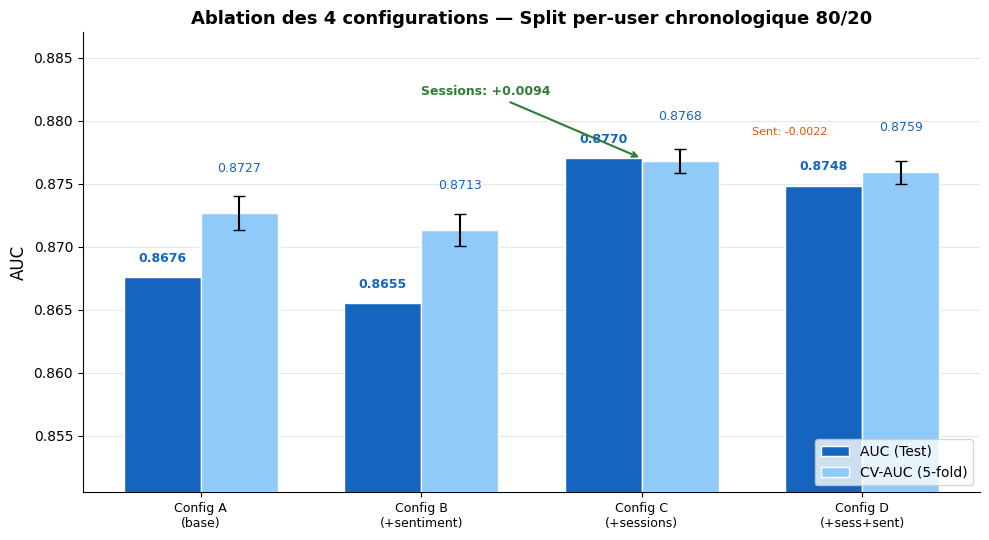

✅ Sauvegardé: plot1_ablation_configs.png


In [19]:
# ═══════════════════════════════════════════════════════════════
# PLOT 1 — Ablation 4 configs (AUC test + CV-AUC)
# ═══════════════════════════════════════════════════════════════
from builtins import min, max
import matplotlib.pyplot as plt
import numpy as np

configs = ['Config A\n(base)', 'Config B\n(+sentiment)', 'Config C\n(+sessions)', 'Config D\n(+sess+sent)']
auc_test = [m_A['auc'], m_B['auc'], m_C['auc'], m_D['auc']]
cv_auc = [m_A['cv_auc_mean'], m_B['cv_auc_mean'], m_C['cv_auc_mean'], m_D['cv_auc_mean']]
cv_std = [m_A['cv_auc_std'], m_B['cv_auc_std'], m_C['cv_auc_std'], m_D['cv_auc_std']]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(4)
w = 0.35
bars1 = ax.bar(x - w/2, auc_test, w, label='AUC (Test)', color='#1565C0', edgecolor='white', zorder=3)
bars2 = ax.bar(x + w/2, cv_auc, w, label='CV-AUC (5-fold)', color='#90CAF9', edgecolor='white', zorder=3,
               yerr=cv_std, capsize=4)
for bar, val in zip(bars1, auc_test):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.4f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1565C0')
for bar, val in zip(bars2, cv_auc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{val:.4f}', 
            ha='center', va='bottom', fontsize=9, color='#1565C0')

# Annotation gains
gain_sess = m_C['auc'] - m_A['auc']
gain_sent = m_D['auc'] - m_C['auc']
ax.annotate(f'Sessions: {gain_sess:+.4f}', xy=(2, m_C['auc']), xytext=(1.0, m_C['auc']+0.005),
            fontsize=9, color='#2E7D32', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1.5))
ax.annotate(f'Sent: {gain_sent:+.4f}', xy=(3, m_D['auc']), xytext=(2.5, m_D['auc']+0.004),
            fontsize=8, color='#E65100')

ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Ablation des 4 configurations — Split per-user chronologique 80/20', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=9)
ax.set_ylim(min(auc_test + cv_auc) - 0.015, max(auc_test) + 0.01)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot1_ablation_configs.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé: plot1_ablation_configs.png")

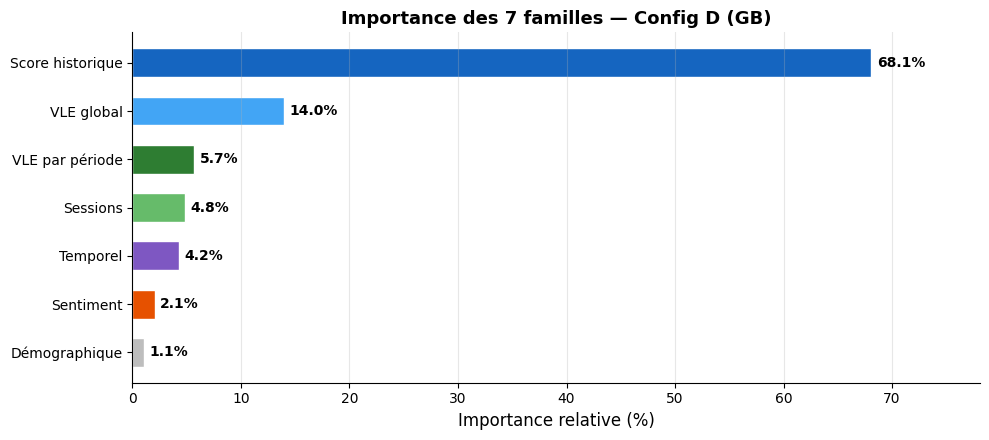

✅ Sauvegardé: plot2_feature_importance.png


In [20]:
# ═══════════════════════════════════════════════════════════════
# PLOT 2 — Importance des 7 familles (depuis gb_D)
# ═══════════════════════════════════════════════════════════════

imp_groups = {
    'Score historique': score_imp / total_imp * 100,
    'VLE global': vle_global_imp / total_imp * 100,
    'Sessions': session_imp / total_imp * 100,
    'Temporel': temporal_imp / total_imp * 100,
    'VLE par période': vle_period_imp / total_imp * 100,
    'Sentiment': sent_imp / total_imp * 100,
    'Démographique': demo_imp / total_imp * 100,
}

# Trier par importance décroissante
sorted_items = sorted(imp_groups.items(), key=lambda x: x[1])
families = [item[0] for item in sorted_items]
values = [item[1] for item in sorted_items]
colors_imp = ['#BDBDBD', '#E65100', '#7E57C2', '#66BB6A', '#2E7D32', '#42A5F5', '#1565C0']

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(families, values, color=colors_imp, height=0.6, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Importance relative (%)', fontsize=12)
ax.set_title('Importance des 7 familles — Config D (GB)', fontsize=13, fontweight='bold')
ax.set_xlim(0, max(values) + 10)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot2_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé: plot2_feature_importance.png")

In [21]:
from builtins import abs, min, max
# Diagnostic — vérifier la cohérence
print(f"X_test_C shape: {X_test_C.shape}")
print(f"X_test_D shape: {X_test_D.shape}")
print(f"y_test shape: {y_test.shape}")

# Recalculer les AUC pour vérifier
proba_C_check = gb_C.predict_proba(X_test_C)[:, 1]
proba_D_check = gb_D.predict_proba(X_test_D)[:, 1]

auc_c_check = roc_auc_score(y_test, proba_C_check)
auc_d_check = roc_auc_score(y_test, proba_D_check)

print(f"\nAUC Config C recalculée: {auc_c_check:.4f} (attendu: {m_C['auc']:.4f})")
print(f"AUC Config D recalculée: {auc_d_check:.4f} (attendu: {m_D['auc']:.4f})")
print(f"Match C: {'✅' if abs(auc_c_check - m_C['auc']) < 0.0001 else '❌'}")
print(f"Match D: {'✅' if abs(auc_d_check - m_D['auc']) < 0.0001 else '❌'}")

X_test_C shape: (27331, 62)
X_test_D shape: (27331, 66)
y_test shape: (27331,)

AUC Config C recalculée: 0.8770 (attendu: 0.8770)
AUC Config D recalculée: 0.8748 (attendu: 0.8748)
Match C: ✅
Match D: ✅


Zone incertaine (δ < 0.15): n=1756, AUC_C=0.5794, AUC_D=0.5821, ΔAUC=+0.0027
Zone confiante (δ ≥ 0.45): n=17641, AUC_C=0.7761, AUC_D=0.7660, ΔAUC=-0.0101


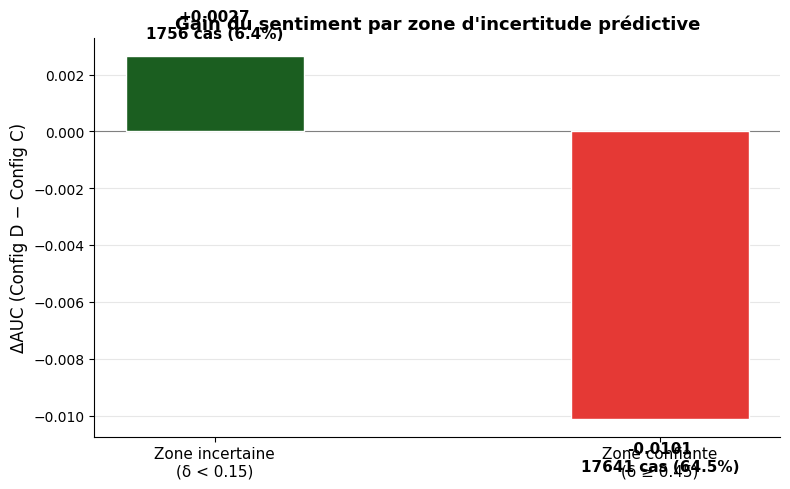

✅ Sauvegardé: plot3_differential_analysis.png


In [22]:
# ═══════════════════════════════════════════════════════════════
# PLOT 3 — Analyse différentielle (2 zones)
# ═══════════════════════════════════════════════════════════════
from builtins import min, max

proba_C = gb_C.predict_proba(X_test_C)[:, 1]
proba_D = gb_D.predict_proba(X_test_D)[:, 1]

delta_C = np.abs(proba_C - 0.5)

zones_def = [
    ("Zone incertaine\n(δ < 0.15)", delta_C < 0.15),
    ("Zone confiante\n(δ ≥ 0.45)", delta_C >= 0.45),
]

z_names, z_deltas, z_n, z_colors = [], [], [], []
for name, mask in zones_def:
    n = mask.sum()
    if n < 50 or len(np.unique(y_test[mask])) < 2:
        continue
    auc_c = roc_auc_score(y_test[mask], proba_C[mask])
    auc_d = roc_auc_score(y_test[mask], proba_D[mask])
    d_auc = auc_d - auc_c
    z_names.append(name)
    z_deltas.append(d_auc)
    z_n.append(f'{n} cas ({n/len(y_test)*100:.1f}%)')
    z_colors.append('#1B5E20' if d_auc >= 0 else '#E53935')
    print(f"{name.replace(chr(10), ' ')}: n={n}, AUC_C={auc_c:.4f}, AUC_D={auc_d:.4f}, ΔAUC={d_auc:+.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(z_names)), z_deltas, color=z_colors, width=0.4, edgecolor='white', zorder=3)
for i, (bar, val, n) in enumerate(zip(bars, z_deltas, z_n)):
    sign = '+' if val >= 0 else ''
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + (0.0005 if val >= 0 else -0.0008),
            f'{sign}{val:.4f}\n{n}', ha='center', 
            va='bottom' if val >= 0 else 'top', fontsize=11, fontweight='bold')

ax.axhline(y=0, color='gray', linewidth=0.8)
ax.set_xticks(range(len(z_names)))
ax.set_xticklabels(z_names, fontsize=11)
ax.set_ylabel('ΔAUC (Config D − Config C)', fontsize=12)
ax.set_title('Gain du sentiment par zone d\'incertitude prédictive', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot3_differential_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé: plot3_differential_analysis.png")

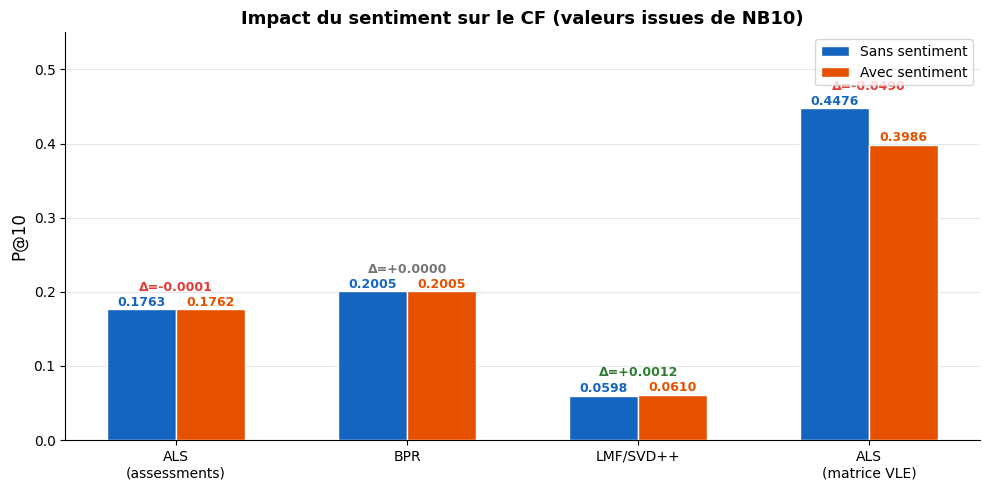

✅ Sauvegardé: plot4_cf_baselines.png


In [23]:
# ═══════════════════════════════════════════════════════════════
# PLOT 4 — CF baselines (valeurs issues de NB10)
# ═══════════════════════════════════════════════════════════════
# Note : ces valeurs proviennent du notebook 10_benchmarking_ALS_BPR_SVDpp
# et ne sont pas recalculées ici.

algos = ['ALS\n(assessments)', 'BPR', 'LMF/SVD++', 'ALS\n(matrice VLE)']
p10_sans = [0.1763, 0.2005, 0.0598, 0.4476]
p10_avec = [0.1762, 0.2005, 0.0610, 0.3986]
gains = [p10_avec[i] - p10_sans[i] for i in range(4)]

fig, ax = plt.subplots(figsize=(10, 5))
x4 = np.arange(len(algos))
w4 = 0.3
ax.bar(x4 - w4/2, p10_sans, w4, label='Sans sentiment', color='#1565C0', edgecolor='white', zorder=3)
ax.bar(x4 + w4/2, p10_avec, w4, label='Avec sentiment', color='#E65100', edgecolor='white', zorder=3)
for i, (s, a, g) in enumerate(zip(p10_sans, p10_avec, gains)):
    ax.text(i - w4/2, s + 0.005, f'{s:.4f}', ha='center', fontsize=9, fontweight='bold', color='#1565C0')
    ax.text(i + w4/2, a + 0.005, f'{a:.4f}', ha='center', fontsize=9, fontweight='bold', color='#E65100')
    sign = '+' if g >= 0 else ''
    color = '#2E7D32' if g > 0 else '#E53935' if g < 0 else '#757575'
    ax.text(i, max(s, a) + 0.025, f'Δ={sign}{g:.4f}', ha='center', fontsize=9, fontweight='bold', color=color)

ax.set_ylabel('P@10', fontsize=12)
ax.set_title('Impact du sentiment sur le CF (valeurs issues de NB10)', fontsize=13, fontweight='bold')
ax.set_xticks(x4)
ax.set_xticklabels(algos, fontsize=10)
ax.legend(loc='upper right')
ax.set_ylim(0, 0.55)
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('plot4_cf_baselines.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Sauvegardé: plot4_cf_baselines.png")

In [24]:
# ============================================================
# PRODUCTION — GB-LTR Config D : artefacts pour la démo
# ============================================================
import joblib, json

# 1) Modèle final Config D
joblib.dump(gb_D, "/kaggle/working/gb_ltr_D.pkl")

# 2) Liste des features dans l'ordre EXACT d'entraînement
#    (features_nb11b_all est une liste ordonnée — c'est l'ordre vu par le modèle)
with open("/kaggle/working/gb_ltr_features.json", "w") as f:
    json.dump(list(features_nb11b_all), f, indent=2)

# 3) Jeu de test complet avec identifiants -> lookup en démo, zéro Spark
cols = ['id_student', 'id_assessment', 'label'] + list(features_nb11b_all)
test_pdf[cols].to_csv("/kaggle/working/gb_ltr_test.csv", index=False)

# 4) Métadonnées (hyperparamètres + métriques tracées depuis le run, non inventées)
meta_ltr = {
    "modele": "GradientBoostingClassifier (sklearn) — Config D",
    "role": "PRODUCTION recommandation cas nominal (Learning-to-Rank)",
    "n_features": len(features_nb11b_all),
    "GB_PARAMS": GB_PARAMS,
    "metriques": m_D,   # dict retourné par train_and_eval pour Config D
}
with open("/kaggle/working/gb_ltr_meta.json", "w") as f:
    json.dump(meta_ltr, f, indent=2, default=str)

print("Artefacts sauvegardes :")
print("  - gb_ltr_D.pkl")
print("  - gb_ltr_features.json")
print("  - gb_ltr_test.csv", test_pdf[cols].shape)
print("  - gb_ltr_meta.json")

Artefacts sauvegardes :
  - gb_ltr_D.pkl
  - gb_ltr_features.json
  - gb_ltr_test.csv (27331, 69)
  - gb_ltr_meta.json


In [25]:
import json
# Les 7 familles de signaux (Config D) — noms de colonnes réels
familles = {
    "Clics VLE (global)":       list(features_vle_global),
    "Temporel":                 list(features_temporal),
    "Démographie":              list(features_demo),
    "Historique de scores":     list(features_score_hist),
    "Sessions":                 list(features_session),
    "Clics VLE (par période)":  list(features_vle_period),
    "Sentiment (historique)":   list(features_sent_hist),
}
with open("/kaggle/working/ltr_feature_families.json", "w", encoding="utf-8") as f:
    json.dump(familles, f, indent=2, ensure_ascii=False)

# Importances du modèle Config D (par feature) — tracées depuis gb_D
imp = {str(r['feature']): float(r['importance']) for _, r in feat_imp.iterrows()}
with open("/kaggle/working/ltr_importance.json", "w", encoding="utf-8") as f:
    json.dump(imp, f, indent=2, ensure_ascii=False)

print("OK :", {k: len(v) for k, v in familles.items()}, "| features importance:", len(imp))

OK : {'Clics VLE (global)': 20, 'Temporel': 4, 'Démographie': 5, 'Historique de scores': 5, 'Sessions': 8, 'Clics VLE (par période)': 20, 'Sentiment (historique)': 4} | features importance: 66
